In [1]:
import pathlib
from os import path, getcwd, chdir

import numpy as np
from tqdm import tqdm

chdir(r'C:\Users\IanFu\Desktop\~1_CURRENT\efsprapy\01-analysis\sensitivity_occupancy_type')


def read_data(parent_dir: pathlib.Path) -> (list, list):
    folders = [item for item in parent_dir.iterdir() if item.is_dir()]
    folders.sort()
    processed_data = dict()
    for folder in tqdm(folders):
        case_name = folder.name.split('-')[0]
        separation_distance = float(folder.name.split('-')[-1])
        fp_output = folder / f'{folder.name}_out.csv'
        try:
            assert path.exists(fp_output), f'file does not exist {fp_output}'
        except AssertionError:
            continue
        mcs_output = np.genfromtxt(fp_output, delimiter=",", skip_header=1)

        N = np.shape(mcs_output)[0]

        # find all iterations that ignition occurred
        t_ig_ftp = mcs_output[:, 2]
        P_ig = sum(np.logical_and(t_ig_ftp > 0, t_ig_ftp < np.inf)) / N

        if case_name not in processed_data:
            processed_data[case_name] = dict(sep=list(), pig=list(), )

        processed_data[case_name]['sep'].append(separation_distance)
        processed_data[case_name]['pig'].append(P_ig)
    return processed_data


data = read_data(pathlib.Path(getcwd(), 'occ_type'))

100%|██████████| 324/324 [00:06<00:00, 46.95it/s]


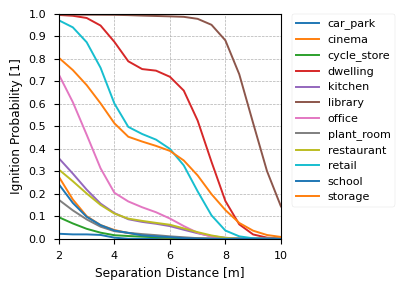

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')

fig, ax = plt.subplots(figsize=(4.2, 3), dpi=100)

lines = dict()
# for occ_type, data_ in data['occ_type'].items():
for occ_type, data_ in data.items():
    lines[occ_type] = ax.plot(*zip(*sorted(zip(data[occ_type]['sep'], data[occ_type]['pig']))), label=occ_type)
ax.set_xlabel("Separation Distance [m]")
ax.set_ylabel("Ignition Probability [1]")
ax.set_xlim(2, 10)
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.grid(which="both", ls="--", lw=0.5)

# br 187 084 base case
# lines = dict()
# for label, data_ in data.items():
#     lines[label] = ax.plot(*data_, label=label)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

fig.tight_layout()

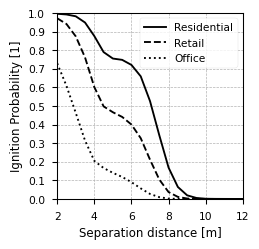

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')

fig, ax = plt.subplots(figsize=(2.8, 2.7), dpi=96)

lines = dict()

lines['dwelling'] = ax.plot(*zip(*sorted(zip(data['dwelling']['sep'], data['dwelling']['pig']))), label='Residential',
                            c='k')
lines['retail'] = ax.plot(*zip(*sorted(zip(data['retail']['sep'], data['retail']['pig']))), label='Retail', c='k',
                          ls='--')
lines['office'] = ax.plot(*zip(*sorted(zip(data['office']['sep'], data['office']['pig']))), label='Office', c='k',
                          ls=':')

ax.set_xlabel("Separation distance [m]")
ax.set_xticks(range(2, 15, 2))
ax.set_xlim(2, 12)
ax.set_ylabel("Ignition Probability [1]")
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.1))

ax.grid(which="both", ls="--", lw=0.5)
ax.legend(loc='upper right')

fig.tight_layout()

In [4]:
data.keys()

dict_keys(['car_park', 'cinema', 'cycle_store', 'dwelling', 'kitchen', 'library', 'office', 'plant_room', 'restaurant', 'retail', 'school', 'storage'])